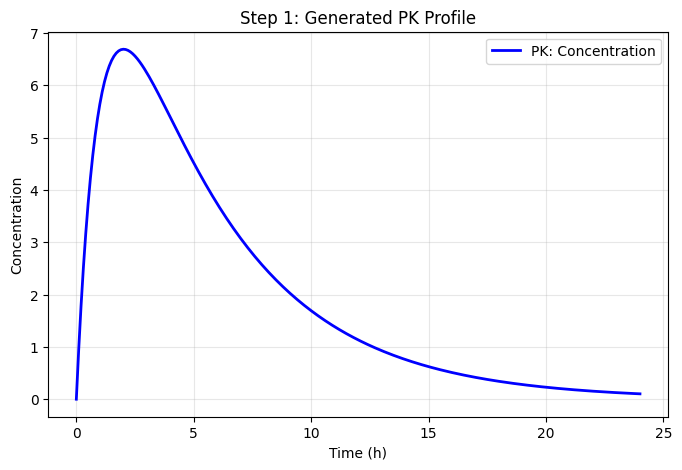

C_max (峰值浓度): 6.6873


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以保证结果可复现
np.random.seed(42)

# ============================
# 1. 生成 PK 数据 (One-Compartment Model)
# ============================

# 参数设定
D = 100.0       # 剂量 (Dose)
V = 10.0        # 分布容积 (Volume)
ka = 1.0        # 吸收速率常数 (1/h)
ke = 0.2        # 消除速率常数 (1/h)
F = 1.0         # 生物利用度

# 定义时间向量 (0 到 24小时, 241个点)
t = np.linspace(0, 24, 241)

# 计算血药浓度 C(t) - Bateman 公式
# C(t) = (F*D*ka / (V*(ka-ke))) * (exp(-ke*t) - exp(-ka*t))
pre_factor = (F * D * ka) / (V * (ka - ke))
C_t = pre_factor * (np.exp(-ke * t) - np.exp(-ka * t))

# 简单的可视化检查
plt.figure(figsize=(8, 5))
plt.plot(t, C_t, 'b-', linewidth=2, label='PK: Concentration')
plt.title('Step 1: Generated PK Profile')
plt.xlabel('Time (h)')
plt.ylabel('Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 打印峰值信息
print(f"C_max (峰值浓度): {np.max(C_t):.4f}")

正在模拟 20 位受试者...


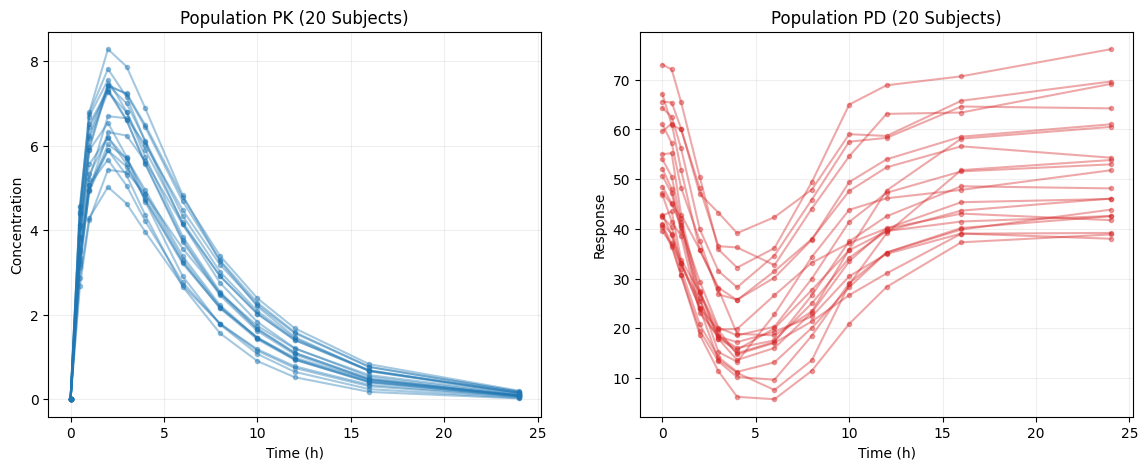

总样本量: 240 (20人 x 12点)
数据列: Time | Concentration | Response


In [2]:
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# ============================
# 2. 生成群体 PK/PD 数据 (Population PK/PD)
# ============================

# --- A. 设定群体参数 (Population Parameters) ---
n_subjects = 20  # 受试者人数
t_clinical = np.array([0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 24.0]) # 稀疏采样点

# 典型值 (Typical Values, TV)
tv_params = {
    'D': 100.0, 'V': 10.0, 'ka': 1.0, 'ke': 0.2,   # PK 参数
    'kin': 25.0, 'kout': 0.5, 'imax': 1.0, 'ec50': 4.0, 'gamma': 3.0 # PD 参数
}

# 个体变异 (Inter-Individual Variability, IIV) - 设定为 10%-20% 的变异系数

iiv_std = 0.15 # 15% 变异

# --- B. 模拟过程 ---
all_data_list = []

# 定义 PD ODE (复用之前的逻辑)
def pd_ode_subject(R, t, kin, kout, imax, ec50, gamma, C_func):
    c_curr = max(C_func(t), 0.0)
    hill = (c_curr**gamma) / (ec50**gamma + c_curr**gamma)
    return kin * (1.0 - imax * hill) - kout * R

# 可视化准备
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

print(f"正在模拟 {n_subjects} 位受试者...")

for i in range(n_subjects):
    # 1. 为该受试者生成个体参数 (Params_i = TV * exp(eta))
    p = {k: v * np.exp(np.random.normal(0, iiv_std)) for k, v in tv_params.items()}
    # 修正：Dose 通常是固定的，Hill系数 gamma 变异通常较小
    p['D'] = tv_params['D']
    p['gamma'] = tv_params['gamma']

    # 2. 计算该受试者的 PK (Bateman函数)
    pre = (p['D'] * p['ka']) / (p['V'] * (p['ka'] - p['ke']))
    C_dense = pre * (np.exp(-p['ke'] * t) - np.exp(-p['ka'] * t)) # 密集曲线用于插值
    C_interp_subj = interp1d(t, C_dense, kind='cubic', fill_value="extrapolate")

    # 3. 计算该受试者的 PD
    R0 = p['kin'] / p['kout']
    # 解微分方程
    R_dense = odeint(pd_ode_subject, R0, t, args=(p['kin'], p['kout'], p['imax'], p['ec50'], p['gamma'], C_interp_subj)).flatten()

    # 4. 提取临床采样点并加噪
    C_obs = C_interp_subj(t_clinical)
    R_true_loc = interp1d(t, R_dense)(t_clinical)
    # 添加残差误差 (Residual Error)
    R_obs = R_true_loc + np.random.normal(0, 0.03 * np.mean(R_dense), size=len(t_clinical))

    # 5. 存储数据 [Time, Conc, Resp]
    subj_data = np.column_stack((t_clinical, C_obs, R_obs))
    all_data_list.append(subj_data)

    # 绘图 (Spaghetti Plot)
    ax1.plot(t_clinical, C_obs, '.-', alpha=0.4, color='tab:blue')
    ax2.plot(t_clinical, R_obs, '.-', alpha=0.4, color='tab:red')

# --- C. 整理最终数据集 ---
# 将所有受试者的数据堆叠在一起
pop_data = np.vstack(all_data_list)

# 绘图装饰
ax1.set_title(f'Population PK ({n_subjects} Subjects)')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Concentration')
ax1.grid(True, alpha=0.2)

ax2.set_title(f'Population PD ({n_subjects} Subjects)')
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Response')
ax2.grid(True, alpha=0.2)
plt.show()

print(f"总样本量: {pop_data.shape[0]} (20人 x 12点)")
print(f"数据列: Time | Concentration | Response")

In [3]:
# ============================
# 3. 导包，项目准备
# ============================
import torch
import torch.nn as nn
from deepymod import DeepMoD, Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.model.func_approx import NN
from deepymod.model.constraint import LeastSquares
from deepymod.model.sparse_estimators import Threshold
from deepymod.training import train
from deepymod.training.sparsity_scheduler import TrainTestPeriodic
from typing import Tuple
from deepymod.utils.types import TensorList
from torch.autograd import grad

# 配置设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on {device}")

D:\PycharmProjects\DeePyMoD\src\deepymod\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Running on cuda


Preprocessing data
Dataset is using device:  cuda
Batch 0 Input (Time) shape: torch.Size([192, 1])
Batch 0 Target (R, C) shape: torch.Size([192, 2])


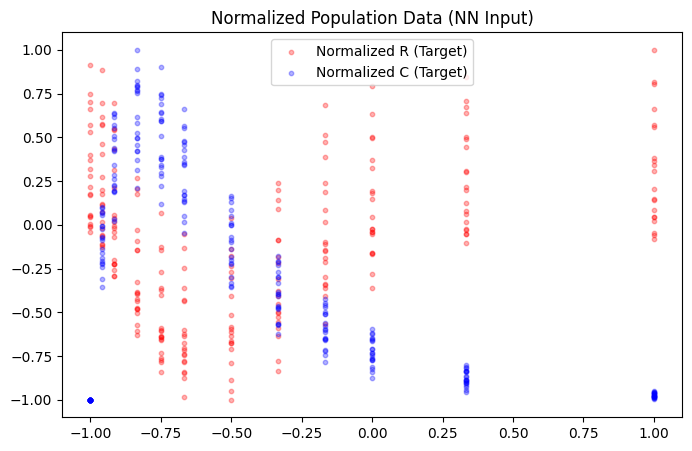

In [4]:
# ============================
# 4. 数据预处理与加载
# ============================

def load_population_data():
    # 输入: Time [N, 1]
    # 我们使用 float32 这里的 N = 240
    t_tensor = torch.tensor(pop_data[:, 0:1], dtype=torch.float32)

    # 目标: [Response, Concentration] [N, 2]
    # 我们让神经网络同时拟合 R 和 C
    # Index 0: Response (R)
    # Index 1: Concentration (C)
    y_tensor = torch.tensor(pop_data[:, [2, 1]], dtype=torch.float32)

    return t_tensor, y_tensor

# 初始化 Dataset
# normalize_coords=True: 时间归一化到 [-1, 1]
# normalize_data=True: 响应和浓度归一化，这对收敛至关重要
dataset = Dataset(
    load_population_data,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": True,
        "normalize_data": True,
    },
    device=device
)

# 划分训练集和测试集
# 现在数据量充足，我们可以留出 20% 作为测试集
train_dataloader, test_dataloader = get_train_test_loader(dataset, train_test_split=0.8)

# 检查一个 Batch
for batch_idx, (input_batch, target_batch) in enumerate(train_dataloader):
    # input_batch: Time
    # target_batch: [R, C]
    if batch_idx == 0:
        print(f"Batch 0 Input (Time) shape: {input_batch.shape}")
        print(f"Batch 0 Target (R, C) shape: {target_batch.shape}")
        break

# 可视化归一化后的数据云
fig, ax = plt.subplots(figsize=(8, 5))
t_norm = dataset.get_coords().cpu()
y_norm = dataset.get_data().cpu()

ax.scatter(t_norm, y_norm[:, 0], s=10, c='r', alpha=0.3, label='Normalized R (Target)')
ax.scatter(t_norm, y_norm[:, 1], s=10, c='b', alpha=0.3, label='Normalized C (Target)')
ax.set_title('Normalized Population Data (NN Input)')
ax.legend()
plt.show()

In [14]:
# ============================
# 5. 构建自动PD建模库
# ============================

class Competitive_Library(Library):
    def __init__(self) -> None:
        super().__init__()

        # 初始化:
        self.hill_ec50 = nn.Parameter(torch.tensor(0.0)) # softplus(0) ≈ 0.69
        self.hill_gamma = nn.Parameter(torch.tensor(2.0)) # softplus(2) ≈ 2.1

    def library(self, input: Tuple[torch.Tensor, torch.Tensor]) -> Tuple[TensorList, TensorList]:
        prediction, data = input
        R = prediction[:, 0:1]
        C = prediction[:, 1:2]

        # 计算导数
        time_deriv_list = []
        for output_idx in range(prediction.shape[1]):
            dy = grad(prediction[:, output_idx], data, grad_outputs=torch.ones_like(prediction[:, output_idx]), create_graph=True)[0]
            time_deriv_list.append(dy[:, 0:1])

        # --- 准备特征项 ---
        C_safe = torch.relu(C) + 1e-6

        h_ec50 = torch.nn.functional.softplus(self.hill_ec50)
        h_gamma = torch.nn.functional.softplus(self.hill_gamma)
        term_Hill = 1.0 / (1.0 + (h_ec50 / C_safe) ** h_gamma)

        one = torch.ones_like(R)

        # --- 组装 Theta ---
        # 0: Constant
        # 1: R
        # 2: Hill
        # 3: R * Hill
        theta = torch.cat((
            one,               # 0
            R,                 # 1
            term_Hill,         # 2
            R * term_Hill      # 3
        ), dim=1)

        return time_deriv_list, [theta, theta]

In [15]:
# ============================
# 6. 配置与初始化模型
# ============================

# 自定义 Ridge 约束器
# 标准 LeastSquares 在处理高度相关的竞争库函数时可能导致矩阵奇异，Ridge 通过正则化解决此问题
class Ridge(nn.Module):
    def __init__(self, lam=1e-3) -> None:
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input: Tuple[TensorList, TensorList]) -> TensorList:
        time_derivs, thetas = input

        # 初始化 Mask
        if self.sparsity_masks is None:
            self.sparsity_masks = [torch.ones(theta.shape[1], dtype=torch.bool).to(theta.device) for theta in thetas]

        # 应用 Mask
        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        # Ridge Regression 拟合
        # w = (X^T X + lam*I)^-1 X^T y
        coeff_vectors = []
        for theta, dt in zip(sparse_thetas, time_derivs):
            # 计算 X^T X
            XtX = theta.T @ theta
            # 添加对角线扰动 (正则化项)
            reg = self.lam * torch.eye(XtX.shape[0]).to(XtX.device)
            # 计算 X^T y
            Xty = theta.T @ dt
            # 求解线性方程组 (比直接求逆更稳健)
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_vectors.append(w)

        # 恢复完整长度的系数向量 (补零)
        full_coeffs = []
        for mask, coeff in zip(self.sparsity_masks, coeff_vectors):
            full_c = torch.zeros((mask.shape[0], 1)).to(coeff.device)
            if mask.sum() > 0:
                full_c[mask] = coeff
            full_coeffs.append(full_c)
        #将结果保存为类属性，供 DeePyMoD 训练循环调用
        self.coeff_vectors = full_coeffs
        return full_coeffs

# 1. 神经网络配置
# 输入: 1 (Time) -> 输出: 2 (Response, Concentration)
network = NN(1, [50, 50, 50, 50], 2)

# 2. 库配置
# 使用我们刚刚定义的竞争型库
library = Competitive_Library()

# 3. 稀疏估计器配置
# Threshold: 小于该值的系数将被置零
estimator = Threshold(0.1)

# 4. 稀疏调度器 (Sparsity Scheduler)
# periodicity=500: 每 500 个 epoch 尝试一次稀疏化
sparsity_scheduler = TrainTestPeriodic(periodicity=500, patience=200, delta=1e-5)

# 5. 约束器 (Constraint)
# 使用 Ridge 回归替代 LeastSquares 以增强数值稳定性
constraint = Ridge(lam=1e-3)

# 6. 实例化模型
model = DeepMoD(network, library, estimator, constraint).to(device)

# 7. 优化器
# 使用 Adam，学习率设为 2e-3
optimizer = torch.optim.Adam(
    model.parameters(),
    betas=(0.99, 0.999),
    amsgrad=True,
    lr=2e-3
)

print("模型配置完成。")
print(model)
print("\n初始猜测参数 (可学习库参数):")
for name, param in model.named_parameters():
    if 'library' in name:
        print(f"  {name}: {param.data.item():.4f}")

模型配置完成。
DeepMoD(
  (func_approx): NN(
    (network): Sequential(
      (0): Linear(in_features=1, out_features=50, bias=True)
      (1): Tanh()
      (2): Linear(in_features=50, out_features=50, bias=True)
      (3): Tanh()
      (4): Linear(in_features=50, out_features=50, bias=True)
      (5): Tanh()
      (6): Linear(in_features=50, out_features=50, bias=True)
      (7): Tanh()
      (8): Linear(in_features=50, out_features=2, bias=True)
    )
  )
  (library): Competitive_Library()
  (sparse_estimator): Threshold()
  (constraint): Ridge()
)

初始猜测参数 (可学习库参数):
  library.hill_ec50: 0.0000
  library.hill_gamma: 2.0000


In [16]:
import os
import torch.nn.functional as F

# ============================
# 7. 训练 DeepPyMoD
# ============================

# 设置日志目录
log_dir = "./logs/pkpd_population/"
if os.path.exists(log_dir):
    import shutil
    shutil.rmtree(log_dir)
os.makedirs(log_dir, exist_ok=True)

print("开始训练... (这可能需要几分钟)")
print("观察随着 MSE 下降，库参数 (library.hill_gamma 等) 的变化")

train(
    model,
    train_dataloader,
    test_dataloader,
    optimizer,
    sparsity_scheduler,
    log_dir=log_dir,
    max_iterations=20000,
    delta=1e-4,
    patience=200,
)

print("\n训练结束！")

# --- 查看最终学到的药理学参数 ---
print("\n[最终参数识别结果]")
print("-" * 30)

lib = model.library

def to_physical(raw_param):
    return F.softplus(raw_param).item()

print(f"Hill Model (核心候选):")
print(f"  Gamma (Hill系数) : {to_physical(lib.hill_gamma):.4f} (初始猜测: {to_physical(torch.tensor(2.5)):.2f})")
print(f"  EC50            : {to_physical(lib.hill_ec50):.4f}")

print(f"\n干扰项参数 (对照组):")

print("-" * 30)

开始训练... (这可能需要几分钟)
观察随着 MSE 下降，库参数 (library.hill_gamma 等) 的变化
 19975  MSE: 1.04e-01  Reg: 1.27e-04  L1: 5.96e+00 Algorithm converged. Writing model to disk.

训练结束！

[最终参数识别结果]
------------------------------
Hill Model (核心候选):
  Gamma (Hill系数) : 0.2233 (初始猜测: 2.58)
  EC50            : 0.0984

干扰项参数 (对照组):
------------------------------


In [17]:
# ============================
# 8. 结果解释与方程重建
# ============================

# 名称列表
library_names = [
    "1",              # 0
    "R",              # 1
    "Hill_Term",      # 2
    "R*Hill_Term"     # 3
]

print("正在解码发现的方程...\n")

# 获取 dR/dt 的稀疏回归结果
mask_R = model.constraint.sparsity_masks[0].detach().cpu().numpy()
coeffs_R = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()

print(f"针对 dR/dt (响应变化率) 的稀疏回归结果:")
print("-" * 50)

found_terms = []
for idx, (is_active, coeff) in enumerate(zip(mask_R, coeffs_R)):
    if idx >= len(library_names): break
    term_name = library_names[idx]

    if is_active:
        sign = "+" if coeff >= 0 else ""
        term_str = f"{sign} {coeff:.4f} * [{term_name}]"
        found_terms.append(term_str)
        print(f"[选中] {term_name:<15} 系数: {coeff:.4f}")

print("-" * 50)
print("最终发现的方程形式 (归一化空间):")
equation = "dR/dt = " + " ".join(found_terms)
print(equation)

# --- 验证逻辑 ---
# 真实的物理方程结构是: dR/dt = Kin - Kout*R - (Kin*Imax)*Hill
# 期望结果: 选中 "1", "R", "Hill_Term" 或 "R*Hill_Term"
has_hill = mask_R[2] or mask_R[3]

print("\n[AI 诊断]")
if has_hill:
    print("SUCCESS: 模型使用了 Hill 机制。")
    print("       请检查上方的 Gamma 和 EC50 值：")
    print("       - 如果 Gamma ≈ 1, 则为 Emax 模型。")
    print("       - 如果 Gamma > 1, 则为 Sigmoid 模型 (您的真实情况)。")
    print("       - 如果 EC50 极大, 则退化为线性模型。")
else:
    print("FAILURE: 未选中任何药物效应项 (这不太可能发生)。")

正在解码发现的方程...

针对 dR/dt (响应变化率) 的稀疏回归结果:
--------------------------------------------------
[选中] 1               系数: 1.2943
[选中] R               系数: -2.3738
[选中] Hill_Term       系数: -7.3462
--------------------------------------------------
最终发现的方程形式 (归一化空间):
dR/dt = + 1.2943 * [1]  -2.3738 * [R]  -7.3462 * [Hill_Term]

[AI 诊断]
SUCCESS: 模型使用了 Hill 机制。
       请检查上方的 Gamma 和 EC50 值：
       - 如果 Gamma ≈ 1, 则为 Emax 模型。
       - 如果 Gamma > 1, 则为 Sigmoid 模型 (您的真实情况)。
       - 如果 EC50 极大, 则退化为线性模型。


In [18]:
# ============================
# 9. 可视化模型预测与药效曲线
# ============================

import matplotlib.pyplot as plt
import numpy as np

# 1. 获取测试集数据并进行预测
# 我们需要把整个测试集拿出来，排序（为了画线），然后喂给模型
X_test_list = []
y_test_list = []

for batch in test_dataloader:
    data, target = batch
    X_test_list.append(data)
    y_test_list.append(target)

X_test = torch.cat(X_test_list, dim=0)
y_test = torch.cat(y_test_list, dim=0)

# 对时间进行排序，方便画线
sort_idx = torch.argsort(X_test[:, 0])
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]

# 模型预测
with torch.no_grad():
    prediction, time_derivs, thetas = model(X_test_sorted)

    # 提取我们关心的变量
    R_pred = prediction[:, 0].cpu().numpy()
    C_pred = prediction[:, 1].cpu().numpy()
    R_true = y_test_sorted[:, 0].cpu().numpy()
    C_true = y_test_sorted[:, 1].cpu().numpy()
    Time = X_test_sorted[:, 0].cpu().numpy()

    # 提取学到的 Hill 函数值
    # 在 V5 库中，theta 的第 2 列 (Index 2) 是 Hill_Term
    # theta[0] 对应 dR/dt 的库
    hill_func_values = thetas[0][:, 2].cpu().numpy()

# 2. 绘图
plt.figure(figsize=(15, 5))

# --- 子图 1: 时间-响应曲线 (拟合效果) ---
plt.subplot(1, 3, 1)
plt.scatter(Time, R_true, c='gray', alpha=0.6, label='Data (Noisy)')
plt.plot(Time, R_pred, 'r-', linewidth=2, label='Model Prediction')
plt.title("PD Response vs Time")
plt.xlabel("Time")
plt.ylabel("Response (R)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 子图 2: 浓度-效应曲线 (学到的机理) ---
# 我们画出 C_pred vs Hill_Term，看看模型学到的曲线形状
plt.subplot(1, 3, 2)
plt.scatter(C_pred, hill_func_values, c='blue', s=10, alpha=0.5, label='Learned Hill Term')

# 为了对比，我们画出该参数下的理论曲线
c_range = np.linspace(0, C_pred.max(), 100)
# 获取学到的参数
gamma_learned = to_physical(model.library.hill_gamma)
ec50_learned = to_physical(model.library.hill_ec50)
hill_theoretical = 1.0 / (1.0 + (ec50_learned / (c_range + 1e-6))**gamma_learned)

plt.plot(c_range, hill_theoretical, 'k--', label=f'Theoretical\n(g={gamma_learned:.2f}, EC50={ec50_learned:.2f})')
plt.title("Learned PD Relationship (Hill Function)")
plt.xlabel("Concentration (C)")
plt.ylabel("E / Emax")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 子图 3: 真正的相平面 (R vs C) ---
plt.subplot(1, 3, 3)
plt.scatter(C_true, R_true, c='gray', alpha=0.5, label='True Data')
plt.plot(C_pred, R_pred, 'g-', label='Model Trajectory')
plt.title("Phase Plane (R vs C)")
plt.xlabel("Concentration (C)")
plt.ylabel("Response (R)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"当前模型参数诊断:")
print(f"Gamma = {gamma_learned:.4f} (期望值 > 1.0)")
print(f"EC50  = {ec50_learned:.4f}")
print("分析提示: 如果中间那张图的散点看起来是一条很平滑的曲线，说明模型学到了规律。")
print("          如果 Gamma 很小，曲线会显得非常平缓，没有明显的 S 形拐点。")

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn